In [10]:
import torch
import torch.nn as nn

In [11]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [12]:
model = LeNet5()
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


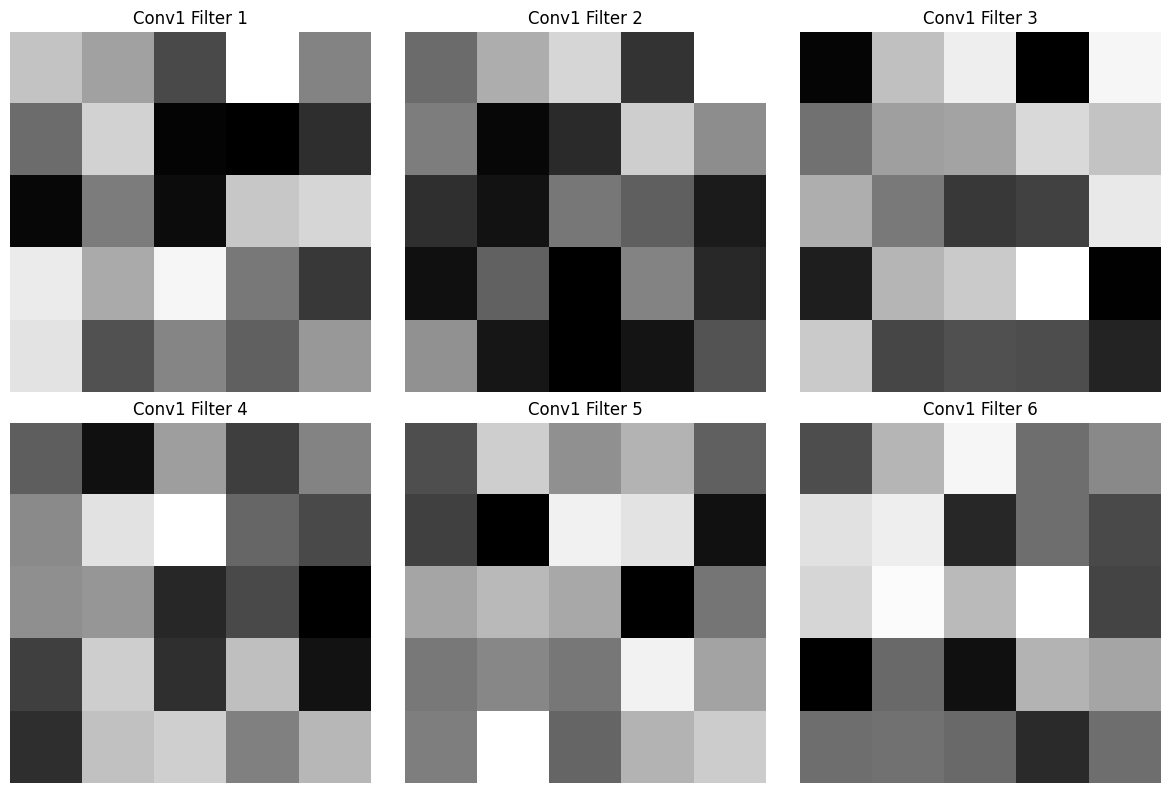

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(6):
    ax = axes[i // 3, i % 3]
    ax.imshow(model.conv1.weight[i, 0].detach().numpy(), cmap='gray')
    ax.set_title(f'Conv1 Filter {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

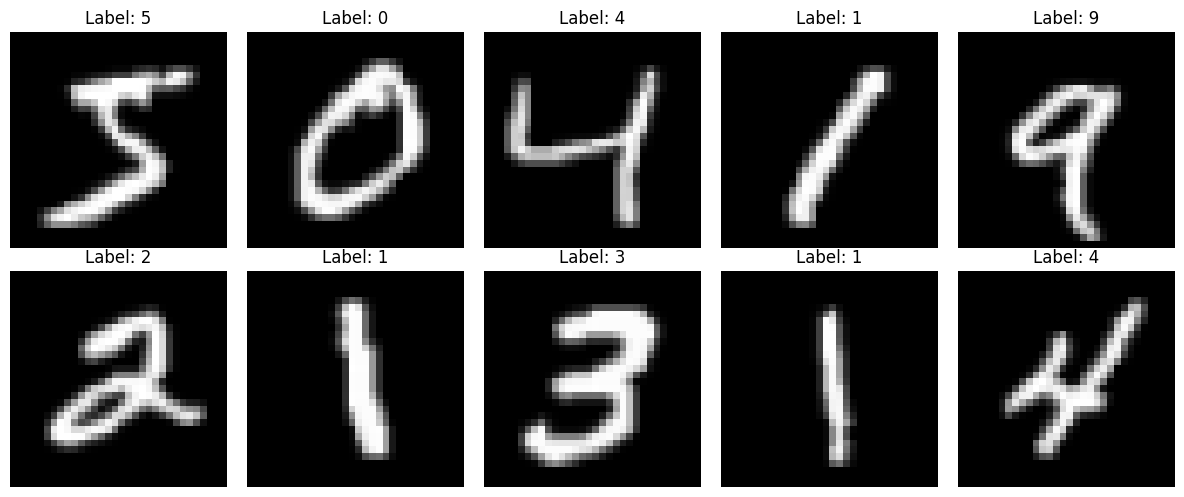

In [14]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor()
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(train_dataset[i][0].squeeze(), cmap='gray')
    ax.set_title(f'Label: {train_dataset[i][1]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [15]:
import torch.optim as optim
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
for epoch in range(epochs):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 1/5, Loss: 0.0159
Epoch 2/5, Loss: 0.1059
Epoch 3/5, Loss: 0.0318
Epoch 4/5, Loss: 0.0260
Epoch 5/5, Loss: 0.0279


In [16]:
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Precisão da IA no conjunto de testes: {accuracy:.2f}%')


Precisão da IA no conjunto de testes: 98.75%


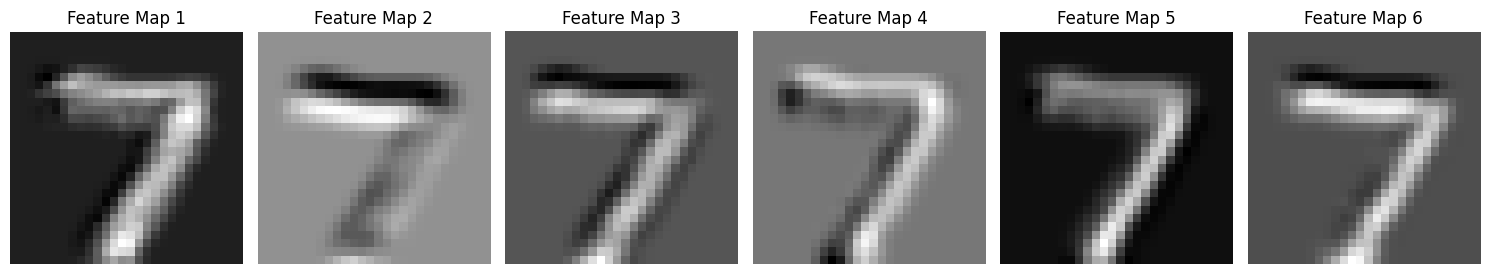

In [18]:
image, label = test_dataset[0]
image_batch = image.unsqueeze(0)

output_conv1 = model.conv1(image_batch)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    axes[i].imshow(output_conv1[0, i].detach().numpy(), cmap='gray')
    axes[i].set_title(f'Feature Map {i+1}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# Salvando o modelo criado

In [17]:
torch.save(model.state_dict(), 'lenet5_model.pth')

# Código pra carregar o modelo treinado e fazer previsões


In [ ]:
model = LeNet5()
model.load_state_dict(torch.load('lenet5_model.pth'))
model.eval()